# Give Me Some Credit — Data Preprocessing
---

## Phase 1: Data Preprocessing & Strategic Foundation

### Beyond Accuracy: Engineering Trust in Financial Risk
> **"A model is only as good as the decisions it informs."**

I initiated this project using the **'Give Me Some Credit'** dataset because it encompasses the universal features essential for a profound understanding of Risk Management. While this dataset was originally designed for a Kaggle competition aimed at maximizing **ROC-AUC scores**, I have intentionally shifted my focus. Instead of merely chasing a higher ranking on a leaderboard, I sought to build a **predictive system tailored for real-world institutional trust.**

I believe that in a professional financial environment, **predictability is less powerful and more risky than those with reliability.** If a model predicts well but lacks statistical reliability (calibration), it becomes a liability rather than an asset. Hence, I asked a more fundamental question: **How can we build a predictive system that a financial institution can actually trust for its bottom-line decisions?**

To answer the question, I view credit risk not as a mathematical puzzle, but as a **systemic challenge of uncertainty**. In the volatile landscape of global finance, the cost of a false prediction isn't just a number—it’s a direct hit to capital stability and regulatory compliance.

---

### My Strategic Goal
The objective of this project is to develop a **Decision-Ready Credit Scoring Pipeline**. My focus has shifted from "predicting a default" to **"quantifying risk with high fidelity."** To achieve this, I have structured the project to demonstrate:

* **Integrity at the Source:** Building a robust foundation through meticulous preprocessing.
* **Evidence-Based Insights:** Uncovering the economic drivers of delinquency through deep EDA.
* **Calibrated Actionability:** Delivering a modeling engine where predicted probabilities translate directly into reliable business risk tiers.

---

### The Roadmap
Based on these goals, this journey is meticulously organized into **three phases** to ensure transparency and statistical rigor:

1.  **Phase 1: Data Preprocessing** – Neutralizing noise to find the 'signal' in financial data.
2.  **Phase 2: Exploratory Data Analysis (EDA)** – Translating statistical correlations into economic insights.
3.  **Phase 3: Advanced Modeling & Strategy** – Bridging the gap between ML metrics and capital allocation strategy.

> *This structured approach ensures that every analytical step is grounded in institutional reliability, starting with the most critical stage: the integrity of the data itself.*

---

### Data Preprocessing Pipeline
#### "Turning Raw Data into a Strategic Asset"

In this phase, we perform comprehensive data preprocessing. The primary objective is to build a high-fidelity foundation for credit scoring by neutralizing noise and addressing systemic biases. This ensures that the downstream predictive models are grounded in a reliable and stable dataset.


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# Loading the dataset
df = pd.read_csv('cs-training.csv')

In [20]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [21]:
# Checking the basic information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [22]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Upon a rigorous inspection of the raw dataset, I identified two critical vulnerabilities that could compromise the integrity of our predictive engine:

#### **1. Strategic Data Gaps**
* **The Issue:** Significant missing values detected in `MonthlyIncome` and `NumberOfDependents` (approx. **20% missing** for income).
* **Economic Insight:** In a credit risk context, I believe that income could imply **many aspects of borrowers such as their professional seniority and social credibility**. Therefore, indiscriminate row deletion would lead to a severe loss of information, potentially causing the model to underestimate risk.

#### **2. Potential Data Leakage**
* **The Issue:** Presence of system-generated identifiers such as `Unnamed: 0`.
* **The Risk:** These non-predictive variables act as conduits for **Data Leakage**, where the model might "cheat" by learning dataset artifacts (like recording order) rather than genuine economic signals. This introduces systemic noise that can fundamentally undermine the model's reliability in a real-world deployment.

---
To address the identified risks, I have established a mitigation strategy that combines statistical rigor with a conservative financial perspective.

#### **Step 1: Distribution-Preserving Imputation**
Handling missing values in financial data requires a balance between statistical accuracy and the preservation of original distribution shapes. I evaluated the following methodologies:

**Evaluated Techniques:**
- **Mean Imputation:** Commonly used but highly sensitive to outliers; in skewed income data, this often pulls the center toward the heavy tail, creating an "optimistic bias."
- **Median Imputation:** A robust statistical measure that maintains the central tendency without being distorted by extreme high-earners.

I compare the outcomes of these techniques by overlaying their resulting distributions against the original raw data. By comparing those outcomes, I will find the most appropriate technique to maximize the models performance on the project's goal.

Similarly, for the `NumberOfDependents` feature, I adopted a conservative imputation strategy. Unlike income, which reflects a continuous economic capacity, family size is a discrete attribute where "inventing" values without explicit documentation could artificially inflate or deflate a borrower’s risk profile. Given the lack of a "proof of burden," I replaced missing entries with 0. This ensures the model remains grounded in declared facts—avoiding the introduction of synthetic household obligations while preserving the overall sample size for deeper behavioral analysis.

#### **Step 2: Dimensionality Refinement (Signal over Noise)**
Upon insepction, variables such as **Unnamed: 0** were identified as purely technical artifacts. These are systemical indices representing the "order of entry". In a predictive risk model, the inclusion of administrative metadata poses a significant threat of **Data Leakage**. If the engine learns patterns based on entry sequence rather than authentic economic signals, the model’s performance will likely collapse when deployed on live data. To mitigate this risk, I systematically dropped these redundant features. This forces the predictive engine to focus exclusively on High-Fidelity Economic Signals, ensuring the final model remains both stable and generalizable across different datasets.

By addressing those two issues, it would lead to a well refined dataset maintaining most information of the original dataset, which won't distract model's performance on predicting potential defaulters and will be able to save a loss from wrong prediction.

##### Mean & Median Imputation Comparison

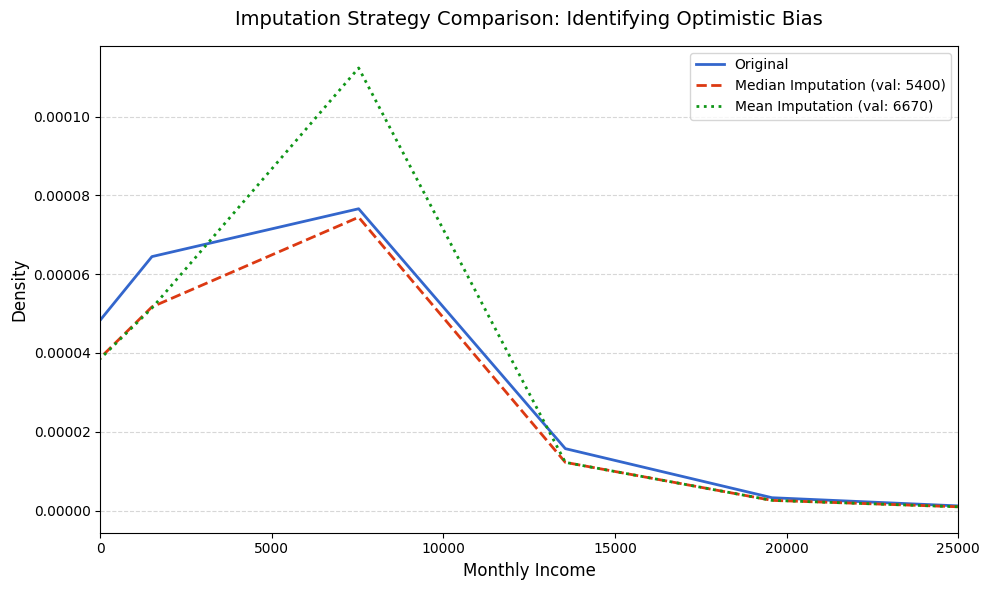

Computed Mean: 6670.22
Computed Median: 5400.00


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Imputation Variations
original_income = df['MonthlyIncome'].dropna()

# Median Imputation (Your current choice)
median_val = df['MonthlyIncome'].median()
median_imputed_income = df['MonthlyIncome'].fillna(median_val)

# Mean Imputation (For Methodological Comparison)
mean_val = df['MonthlyIncome'].mean()
mean_imputed_income = df['MonthlyIncome'].fillna(mean_val)

# 2. Visualization for Methodological Selection
plt.figure(figsize=(10, 6))

# Original Distribution (Baseline)
original_income.plot(kind='kde', color='#3366CC', label='Original', linewidth=2)

# Median Imputation (Robust - follows the original peak)
median_imputed_income.plot(kind='kde', color='#DC3912', label=f'Median Imputation (val: {median_val:.0f})', 
                           linestyle='--', linewidth=2)

# Mean Imputation (Biased - shifts the peak towards higher income)
mean_imputed_income.plot(kind='kde', color='#109618', label=f'Mean Imputation (val: {mean_val:.0f})', 
                         linestyle=':', linewidth=2)

# 3. Formatting
plt.title('Imputation Strategy Comparison: Identifying Optimistic Bias', fontsize=14, pad=15)
plt.xlabel('Monthly Income', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Limit range to focus on the majority of the population (ignoring extreme outliers)
plt.xlim(0, 25000) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Print values to justify the logic in your Markdown
print(f"Computed Mean: {mean_val:.2f}")
print(f"Computed Median: {median_val:.2f}")

Upon executing the comparative analysis, the visual evidence confirms that the Median Imputation (Red Dashed Line) maintains the highest level of compliance with the original dataset's nature. Unlike the Mean approach, which shifts the distribution peak to the right, the Median method stays anchored to the original data's "Center of Gravity."

This technique ensures that we maximize the usable sample size (Quantity) while strictly preserving the authentic economic profile of the population (Quality). This prevents the model from being "distracted" by artificial frequency spikes during the training phase.

--- 

#### Median Imputation & Feature Elimination Implementation

In [24]:
# 1. MonthlyIncome: Distribution-Preserving Imputation
# We use the Median to avoid the "Optimistic Bias" inherent in the Mean
income_median = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median)

# 2. NumberOfDependents: Conservative Attribute Refinement
# We use a constant 0 to avoid "inventing" household burdens without explicit proof
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [25]:
# --- Dimensionality Refinement: Eliminating Systemic Noise ---

# Identify technical artifacts identified during the data diagnosis
target_noise = 'Unnamed: 0'

if target_noise in df.columns:
    # Dropping the feature to mitigate Data Leakage
    df.drop(columns=[target_noise], inplace=True)
    print(f"Successfully removed '{target_noise}': Potential Data Leakage neutralized.")
else:
    print(f"'{target_noise}' not found or already removed: Feature set is refined.")

# Verify final feature set
print(f"Remaining Columns: {df.columns.tolist()}")

Successfully removed 'Unnamed: 0': Potential Data Leakage neutralized.
Remaining Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


#### Output

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
dtype

In [27]:
df.to_csv("processed_data.csv", index=False)
print("Saved to processed_data.csv")

Saved to processed_data.csv


### Key Takeaways from Data Preprocessing
Data Preprocessing focused on neutralizing systemic vulnerabilities and reinforcing data integrity and reliability. This stage ensures that every subsequent analytical finding is built upon a high-fidelity and economically realistic foundation.

#### 1. Strategic Imputation & Distribution Integrity
- `MonthlyIncome (Median Imputation)`: By selecting Median over Mean, I prevented the "Optimistic Bias" inherent in right-skewed income data. This ensures the model is anchored to the population’s authentic central tendency rather than being distorted by extreme high-earners.

- `NumberOfDependents (Conservative Imputation)`: Adopting a conservative financial perspective, I replaced missing entries with 0. This avoids "inventing" household burdens without explicit proof, ensuring the model remains grounded in verified facts.

Post-imputation KDE verification confirms that the core economic characteristics and population distributions remain undistorted.

#### 2. Mitigation of Systemic Noise & Leakage
- **Feature Elimination:** I identified and removed non-predictive system artifacts such as Unnamed: 0. These variables represent dataset artifacts (like recording order) that can act as conduits for Data Leakage. Their removal forces the predictive engine to focus exclusively on High-Fidelity Economic Signals (e.g., debt ratios, delinquency history).

#### 3. Data Quality Readiness
- **Statistical Power:** After missing value treatment and noise reduction, the dataset maintains its full sample size of 150,000 records, maximizing predictive reliability.

- **Version Control:** The refined data has been exported as processed_data.csv, establishing a clean baseline for the modeling pipeline.

### Transition to EDA (Exploratory Data Analysis)
With Integrity at the Source now secured, the project moves to EDA, where we will decode the behavioral patterns driving default risk. The focus will shift to:

1. Feature Behavioral Analysis mapping how refined income and debt ratios interact non-linearly with the target variable (SeriousDlqin2yrs).

2. Outlier Deep-Dive Determining if the extreme values preserved during preprocessing represent valid high-risk signals or require further capping (e.g., Winsorization) to stabilize model training.

3. Multicollinearity Diagnosis Analyzing the high-correlation clusters among delinquency variables to determine the necessity of dimensionality reduction (e.g., PCA) to stabilize linear model coefficients.

A clear lens produces a sharp vision. Having secured a reliable foundation, we now proceed to the Exploratory Data Analysis to identify the primary drivers of credit default risk.